# 问题一：出厂水浊度的滞后相关性分析

本 notebook 独立读取 `data/merged.xlsx`，计算候选变量与出厂水浊度 `NTU` 在 0–24 小时范围内的 Pearson 与 Spearman 滞后相关性，并输出最优滞后阶数、曲线和热力图。

本分析不依赖 `p1.ipynb` 中的数据清洗方案、标准化管线或机器学习模型结果。


In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 输出文件夹
OUTPUT_DIR = Path("outputs/problem1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 自动寻找 merged.xlsx
possible_paths = [
    Path("data/merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("../data/merged.xlsx"),
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Cannot find merged.xlsx. Please check your data path.")

print("Using data file:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Using data file: ../data/merged.xlsx
Output directory: outputs/problem1


## 1. 读取合并后的水质数据

本节继续使用前期数据预处理得到的 `merged.xlsx` 文件。该文件已经完成原始 Excel 附件合并、字段统一、日期重构和基础数据审计，因此本节不再从原始附件重新读取数据，而是直接基于合并后的时间序列数据进行滞后相关性分析。

读取数据后，首先检查数据规模、字段名称和前几行记录，确认目标变量 `NTU` 以及主要候选变量是否存在。

In [42]:
df = pd.read_excel(DATA_PATH)

print("Original shape:", df.shape)
print(df.columns.tolist())
df.head()

Original shape: (5460, 18)
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,PH,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW
0,2025-01-01,07:00:00,6.22,1.0,45.3,150,850.0,7.0,0.04,3.82,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6
1,2025-01-01,09:00:00,6.34,1.0,45.2,120,830.0,7.0,0.05,3.81,7.2,0.12,5.0,1.5,NaN,0.04,2.0,42.6
2,2025-01-01,11:00:00,6.17,1.0,44.9,82,780.0,7.0,0.05,3.81,7.2,0.12,5.0,1.6,NaN,0.04,2.0,42.7
3,2025-01-01,13:00:00,5.99,1.0,44.9,62,720.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.3
4,2025-01-01,15:00:00,5.83,1.0,44.5,56,641.0,7.0,0.05,3.58,7.2,0.11,5.0,1.6,NaN,0.04,2.0,42.5


## 2. 时间字段重构与排序

滞后相关性分析依赖严格的时间顺序，因此需要将 `DATE` 和 `TIME` 合并为统一的 `DATETIME` 字段。随后按照 `DATETIME` 升序排列数据，保证 `shift(lag)` 操作真正表示过去若干时刻的观测值。

这里的时间重构只用于 notebook 内部分析，不改变原始合并数据文件。

In [43]:
# 处理 DATE
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# 处理 TIME
def normalize_time_to_string(x):
    if pd.isna(x):
        return np.nan
    
    # 如果已经是 datetime.time
    if hasattr(x, "hour") and hasattr(x, "minute"):
        return f"{x.hour:02d}:{x.minute:02d}:00"
    
    s = str(x).strip()
    
    # 处理可能出现的 1900-01-01 07:00:00
    if "1900-01-01" in s:
        s = s.replace("1900-01-01", "").strip()
    
    # 处理 07:00:00 / 7:00 / 0700
    if s.isdigit():
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}:00"
    
    try:
        t = pd.to_datetime(s, errors="coerce")
        if pd.isna(t):
            return np.nan
        return t.strftime("%H:%M:%S")
    except Exception:
        return np.nan

df["TIME_STR"] = df["TIME"].apply(normalize_time_to_string)

df["DATETIME"] = pd.to_datetime(
    df["DATE"].dt.strftime("%Y-%m-%d") + " " + df["TIME_STR"],
    errors="coerce"
)

df = df.sort_values("DATETIME").reset_index(drop=True)

print("Data shape:", df.shape)
print("Datetime missing:", df["DATETIME"].isna().sum())
print("Time range:", df["DATETIME"].min(), "to", df["DATETIME"].max())

df[["DATE", "TIME", "TIME_STR", "DATETIME"]].head(15)

Data shape: (5460, 20)
Datetime missing: 0
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00


,DATE,TIME,TIME_STR,DATETIME
0,2025-01-01,07:00:00,07:00:00,2025-01-01 07:00:00
1,2025-01-01,09:00:00,09:00:00,2025-01-01 09:00:00
2,2025-01-01,11:00:00,11:00:00,2025-01-01 11:00:00
3,2025-01-01,13:00:00,13:00:00,2025-01-01 13:00:00
4,2025-01-01,15:00:00,15:00:00,2025-01-01 15:00:00
5,2025-01-01,17:00:00,17:00:00,2025-01-01 17:00:00
6,2025-01-01,19:00:00,19:00:00,2025-01-01 19:00:00
7,2025-01-01,21:00:00,21:00:00,2025-01-01 21:00:00
8,2025-01-01,23:00:00,23:00:00,2025-01-01 23:00:00
9,2025-01-02,01:00:00,01:00:00,2025-01-02 01:00:00


## 3. 候选变量选择

本节的目标变量是出厂水浊度 `NTU`。候选解释变量只选择与水处理过程具有物理联系的核心字段，包括原水浊度、滤后水浊度、原水流量、出厂水流量、清水池水位、明矾投加量、pH、色度和余氯等。

本节不使用 `NTU` 自身作为解释变量，以避免用目标变量预测自身造成信息泄漏。对于 `18ML LEVEL`、`18ML FLOW` 等完全缺失字段，以及缺失率过高且稳定性不足的字段，不纳入本节分析。

In [44]:
target = "NTU"

candidate_features = [
    "R/W NTU",          # 原水浊度
    "FILT. NTU",        # 滤后水浊度
    "R/W FLOW",         # 原水流量
    "T/W FLOW",         # 出厂水流量
    "C/W WELL LEVEL",   # 清水池水位
    "ALUM",             # 明矾/混凝剂投加量
    "R/W PH",           # 原水 pH
    "PH",               # 处理后 pH
    "CLR",              # 处理后色度
    "CL2",              # 余氯
    "RIVER LEVEL",      # 河水水位
    "R/W CLR"           # 原水色度
]

# 只保留数据里实际存在的列
candidate_features = [c for c in candidate_features if c in df.columns]

# 转为数值型
for col in candidate_features + [target]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Candidate features:")
for c in candidate_features:
    print(c)

print("\nTarget missing:", df[target].isna().sum())
print("\nMissing rate of candidate features:")
print((df[candidate_features].isna().mean() * 100).sort_values(ascending=False))

Candidate features:
R/W NTU
FILT. NTU
R/W FLOW
T/W FLOW
C/W WELL LEVEL
ALUM
R/W PH
PH
CLR
CL2
RIVER LEVEL
R/W CLR

Target missing: 336

Missing rate of candidate features:
CL2               31.263736
ALUM              30.109890
R/W PH            30.109890
PH                30.109890
R/W NTU            0.000000
FILT. NTU          0.000000
R/W FLOW           0.000000
T/W FLOW           0.000000
C/W WELL LEVEL     0.000000
CLR                0.000000
RIVER LEVEL        0.000000
R/W CLR            0.000000
dtype: float64


## 4. Pearson 与 Spearman 滞后相关性计算

本节同时计算 Pearson 和 Spearman 两种相关系数。Pearson 相关系数用于衡量变量与 `NTU` 之间的线性关系，Spearman 相关系数基于秩次，能够反映更一般的单调关系，对极端值和偏态分布相对更稳健。

对于每个候选变量，程序依次构造 `lag0` 至 `lag12` 的滞后项，并计算其与当前 `NTU` 的相关性。所有滞后相关性结果保存为 `lag_correlation_all.csv`，其中包含变量名、滞后阶数、滞后小时数、有效样本数、Pearson 相关系数和 Spearman 相关系数。

In [45]:
max_lag = 12       # lag0 到 lag12；每阶 2 小时，最大 24 小时
min_valid_n = 100  # 有效样本太少就不算

records = []

for feature in candidate_features:
    for lag in range(0, max_lag + 1):
        x_lagged = df[feature].shift(lag)
        y = df[target]
        
        temp = pd.DataFrame({
            "x": x_lagged,
            "y": y
        }).dropna()
        
        n = len(temp)
        
        if n < min_valid_n:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = temp["x"].corr(temp["y"], method="pearson")
            spearman_corr = temp["x"].corr(temp["y"], method="spearman")
        
        records.append({
            "feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "valid_n": n,
            "pearson_corr": pearson_corr,
            "pearson_abs": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "spearman_corr": spearman_corr,
            "spearman_abs": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
        })

lag_corr_df = pd.DataFrame(records)

lag_corr_path = OUTPUT_DIR / "lag_correlation_all.csv"
lag_corr_df.to_csv(lag_corr_path, index=False, encoding="utf-8-sig")

print("Saved:", lag_corr_path)
lag_corr_df.head(20)

Saved: outputs/problem1/lag_correlation_all.csv


,feature,lag,lag_hours,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
0,R/W NTU,0,0,5124,0.023184,0.023184,-0.157045,0.157045
1,R/W NTU,1,2,5123,0.028171,0.028171,-0.153928,0.153928
2,R/W NTU,2,4,5122,0.033317,0.033317,-0.148829,0.148829
3,R/W NTU,3,6,5121,0.038702,0.038702,-0.144370,0.144370
4,R/W NTU,4,8,5120,0.043759,0.043759,-0.141559,0.141559
5,R/W NTU,5,10,5119,0.046032,0.046032,-0.138963,0.138963
6,R/W NTU,6,12,5118,0.047153,0.047153,-0.136565,0.136565
7,R/W NTU,7,14,5117,0.046279,0.046279,-0.134438,0.134438
8,R/W NTU,8,16,5116,0.043396,0.043396,-0.132577,0.132577
9,R/W NTU,9,18,5115,0.041189,0.041189,-0.131405,0.131405


## 5. 最优滞后阶数筛选

在得到所有滞后阶数的相关性后，本节分别按照 Pearson 和 Spearman 相关系数的绝对值，为每个候选变量选取相关性最强的滞后阶数。其基本思想为：

$$
\tau_i=\underset{k \in \{0,1,\ldots,12\}}{\arg\max}\ |\rho_i(k)|
$$

其中，\(\tau_i\) 表示变量 \(x_i\) 的候选最优滞后阶数，\(\rho_i(k)\) 表示变量 \(x_i\) 在第 \(k\) 阶滞后下与当前 `NTU` 的相关系数。

需要注意的是，数学上相关性最大的滞后阶数不一定直接作为最终模型特征。后续仍需结合物理意义、缺失情况和相关性强度进行筛选，避免将噪声性或难以解释的长滞后项直接纳入模型。

In [46]:
# Pearson 最强 lag
best_pearson = (
    lag_corr_df
    .dropna(subset=["pearson_abs"])
    .sort_values(["feature", "pearson_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_pearson = best_pearson[
    ["feature", "lag", "lag_hours", "valid_n", "pearson_corr", "pearson_abs"]
].rename(columns={
    "lag": "best_lag_pearson",
    "lag_hours": "best_lag_hours_pearson",
    "valid_n": "valid_n_pearson"
})

# Spearman 最强 lag
best_spearman = (
    lag_corr_df
    .dropna(subset=["spearman_abs"])
    .sort_values(["feature", "spearman_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_spearman = best_spearman[
    ["feature", "lag", "lag_hours", "valid_n", "spearman_corr", "spearman_abs"]
].rename(columns={
    "lag": "best_lag_spearman",
    "lag_hours": "best_lag_hours_spearman",
    "valid_n": "valid_n_spearman"
})

best_lag_summary = pd.merge(
    best_pearson,
    best_spearman,
    on="feature",
    how="outer"
)

best_lag_path = OUTPUT_DIR / "best_lag_summary.csv"
best_lag_summary.to_csv(best_lag_path, index=False, encoding="utf-8-sig")

print("Saved:", best_lag_path)
best_lag_summary

Saved: outputs/problem1/best_lag_summary.csv


,feature,best_lag_pearson,best_lag_hours_pearson,valid_n_pearson,pearson_corr,pearson_abs,best_lag_spearman,best_lag_hours_spearman,valid_n_spearman,spearman_corr,spearman_abs
0,ALUM,11,22,3469,0.040155,0.040155,1,2,3479,-0.030688,0.030688
1,C/W WELL LEVEL,0,0,5124,-0.078290,0.078290,12,24,5112,0.101641,0.101641
2,CL2,0,0,3417,-0.135404,0.135404,1,2,3416,-0.145098,0.145098
3,CLR,0,0,5124,-0.482685,0.482685,0,0,5124,-0.109983,0.109983
4,FILT. NTU,0,0,5124,0.694743,0.694743,1,2,5123,0.232051,0.232051
5,PH,12,24,3468,0.050013,0.050013,12,24,3468,0.177107,0.177107
6,R/W CLR,12,24,5112,0.036846,0.036846,0,0,5124,-0.169043,0.169043
7,R/W FLOW,1,2,5123,0.144300,0.144300,1,2,5123,0.379603,0.379603
8,R/W NTU,12,24,5112,0.050883,0.050883,0,0,5124,-0.157045,0.157045
9,R/W PH,4,8,3476,-0.091544,0.091544,12,24,3468,-0.216993,0.216993


## 6. 滞后相关性曲线

为更直观地观察核心变量与出厂水浊度之间的滞后关系，本节绘制主要变量在不同滞后时间下的 Pearson 相关性曲线。横轴表示滞后时间，纵轴表示对应滞后项与当前 `NTU` 的相关系数。

如果某个变量的相关性在短滞后时间内较高，说明该变量可能对出厂水浊度具有较直接的短期影响；如果相关性随滞后时间增加迅速下降，说明其主要作用集中在当前或较短时间范围内；如果所有滞后下相关性均较弱，则说明该变量对 `NTU` 的简单线性滞后关系不明显。

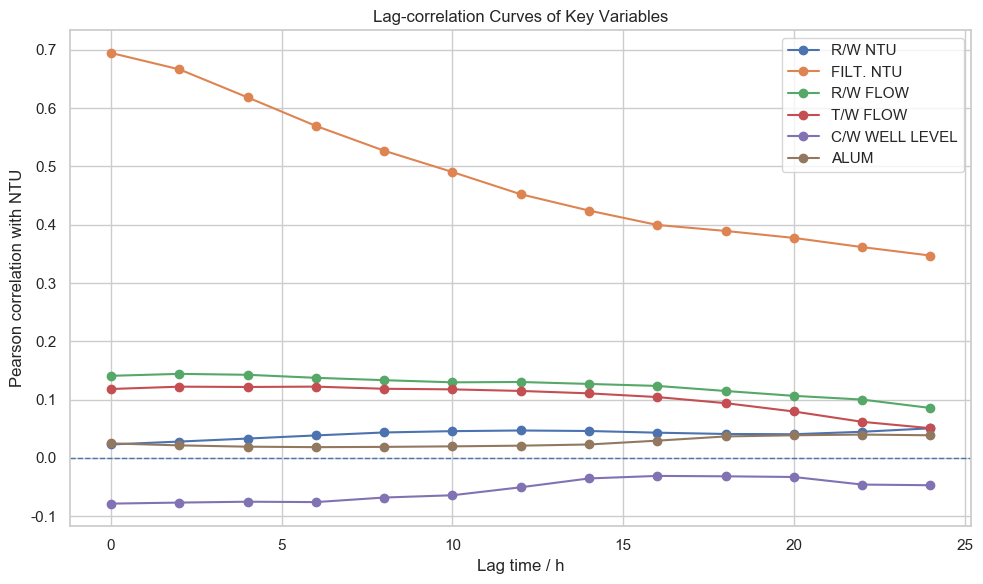

Saved: outputs/problem1/lag_correlation_curves_key_features.png


In [47]:
selected_plot_features = [
    "R/W NTU",
    "FILT. NTU",
    "R/W FLOW",
    "T/W FLOW",
    "C/W WELL LEVEL",
    "ALUM"
]

selected_plot_features = [f for f in selected_plot_features if f in candidate_features]

plt.figure(figsize=(10, 6))

for feature in selected_plot_features:
    temp = lag_corr_df[lag_corr_df["feature"] == feature]
    plt.plot(
        temp["lag_hours"],
        temp["pearson_corr"],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag time / h")
plt.ylabel("Pearson correlation with NTU")
plt.title("Lag-correlation Curves of Key Variables")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "lag_correlation_curves_key_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

## 7. 滞后相关性热力图

热力图用于同时展示所有候选变量在不同滞后时间下与 `NTU` 的 Pearson 相关性。颜色越深表示相关性绝对值越大，正负号表示相关方向。

该图主要用于辅助判断变量的滞后模式。例如，若某变量在 `lag0` 或 `lag1` 附近相关性最强，则说明其影响更偏向同期或短期；若某变量在较长滞后下才出现较高相关性，则需要结合水处理过程判断该滞后是否具有合理物理解释。

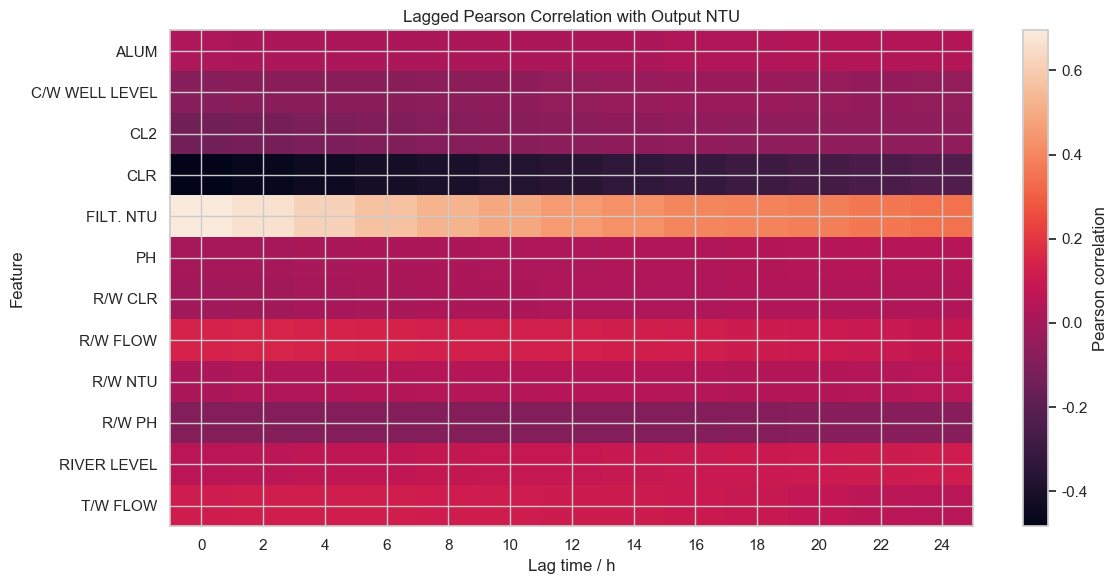

Saved: outputs/problem1/lag_pearson_heatmap.png


In [48]:
heatmap_data = lag_corr_df.pivot(
    index="feature",
    columns="lag_hours",
    values="pearson_corr"
)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Pearson correlation")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Lag time / h")
plt.ylabel("Feature")
plt.title("Lagged Pearson Correlation with Output NTU")

plt.tight_layout()

heatmap_path = OUTPUT_DIR / "lag_pearson_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print("Saved:", heatmap_path)

## 8. 滞后相关性分析小结

滞后相关性分析用于判断候选变量是否存在明显的时间延迟关系。结果显示，并非所有变量都具有强滞后相关性，因此后续建模不能机械地将所有变量的高阶滞后项全部纳入模型。

在后续 Selected-lag 模型中，应优先选择同时满足以下条件的特征：

1. 与 `NTU` 的相关性相对较强；
2. 滞后时间具有合理的水处理过程解释；
3. 变量缺失率较低或经过合理处理；
4. 不会造成明显的信息泄漏。

因此，后续模型将基于相关性强度和物理意义，筛选少量合理的滞后特征进入 Random Forest 和 XGBoost，而不是直接使用所有变量的数学最优滞后项。